# Multi‑Env Opponent Modeling — Env Sanity Check
This notebook quickly verifies that **OpenSpiel**'s *Kuhn* and *Leduc* environments run correctly, shows action histories as they develop, and prints final returns.

**Prereqs**: Your virtualenv should already have `open_spiel` (pyspiel), `numpy`, `matplotlib` installed.


In [1]:

# Imports
import numpy as np
import matplotlib.pyplot as plt
import random, math, sys, os
import pyspiel  # from open_spiel
print("pyspiel version OK. Games available:", [g.short_name for g in pyspiel.registered_games()])


pyspiel version OK. Games available: ['2048', 'add_noise', 'amazons', 'backgammon', 'bargaining', 'battleship', 'blackjack', 'blotto', 'breakthrough', 'bridge', 'bridge_uncontested_bidding', 'cached_tree', 'catch', 'checkers', 'chess', 'cliff_walking', 'clobber', 'coin_game', 'colored_trails', 'connect_four', 'coop_box_pushing', 'coop_to_1p', 'coordinated_mp', 'crazy_eights', 'cribbage', 'cursor_go', 'dark_chess', 'dark_hex', 'dark_hex_ir', 'deep_sea', 'dots_and_boxes', 'dou_dizhu', 'efg_game', 'einstein_wurfelt_nicht', 'euchre', 'first_sealed_auction', 'gin_rummy', 'go', 'goofspiel', 'hanabi', 'havannah', 'hearts', 'hex', 'hive', 'kriegspiel', 'kuhn_poker', 'laser_tag', 'latent_ttt', 'leduc_poker', 'lewis_signaling', 'liars_dice', 'liars_dice_ir', 'lines_of_action', 'maedn', 'mancala', 'markov_soccer', 'matching_pennies_3p', 'matrix_bos', 'matrix_brps', 'matrix_cd', 'matrix_coordination', 'matrix_mp', 'matrix_pd', 'matrix_rps', 'matrix_rpsw', 'matrix_sh', 'matrix_shapleys_game', 'mfg_

## Minimal wrappers
We keep these ultra-thin so they mirror your project interfaces.

In [2]:
CHANCE = pyspiel.PlayerId.CHANCE  # == -1

class OpenSpielEnv:
    def __init__(self, game_name: str):
        self._game = pyspiel.load_game(game_name)
        self._state = None
        self.name = game_name
        self.num_players = self._game.num_players()
        self.action_dim = self._game.num_distinct_actions()

    def reset(self):
        self._state = self._game.new_initial_state()
        return self._state

    def current_player(self):
        return self._state.current_player()

    def is_chance(self):
        return self._state.is_chance_node()

    def chance_outcomes(self):
        # returns list of (action, prob)
        return self._state.chance_outcomes()

    def legal_actions(self):
        return self._state.legal_actions()

    def observation(self, player):
        return self._state.information_state_string(player)

    def action_to_string(self, player, a):
        # For chance nodes, pass CHANCE as player id.
        return self._game.action_to_string(player, a)

    def history(self):
        return self._state.history()

    def is_terminal(self):
        return self._state.is_terminal()

    def step(self, a: int):
        self._state.apply_action(a)

    def returns(self):
        return self._state.returns()

## Simple uniform policy for smoke tests
Choosing uniformly among legal actions.

In [3]:

def uniform_act(env: OpenSpielEnv, player: int, rng: random.Random):
    legal = env.legal_actions()
    return rng.choice(legal)


## Rollout helpers

In [4]:

from dataclasses import dataclass
from typing import List, Dict, Any, Tuple

@dataclass
class StepLog:
    player: int
    legal: list
    action: int
    action_str: str
    info_state: str
    history_ids: list

def sample_chance(outcomes, rng: random.Random):
    # outcomes: list[(action, prob)]
    r, cum = rng.random(), 0.0
    for a, p in outcomes:
        cum += p
        if r <= cum:
            return a
    return outcomes[-1][0]

def play_episode(env: OpenSpielEnv, rng=None) -> Tuple[list[StepLog], list[float]]:
    rng = rng or random.Random(0)
    env.reset()
    logs: List[StepLog] = []
    while not env.is_terminal():
        p = env.current_player()
        a = uniform_act(env, p, rng)
        step = StepLog(
            player=p,
            legal=env.legal_actions(),
            action=a,
            action_str=env.action_to_string(p, a),
            info_state=env.observation(p),
            history_ids=env.history().copy()
        )
        logs.append(step)
        env.step(a)
    return logs, env.returns()

def pretty_print_episode(env_name: str, logs: List[StepLog], rets: List[float]):
    print(f"\n=== {env_name.upper()} EPISODE ===")
    for i, s in enumerate(logs):
        print(f"t={i:02d} | P{s.player} | legal={s.legal} | a={s.action} ({s.action_str}) | hist={s.history_ids}\n   infoset: {s.info_state}")
    print("returns:", rets)


## Run a few episodes in **Kuhn Poker**


=== KUHN EPISODE ===
t=00 | C | a=1 (Deal:1) | hist=[]
   infoset: <CHANCE>
t=01 | C | a=0 (Deal:0) | hist=[1]
   infoset: <CHANCE>
t=02 | P0 | a=1 (Bet) | hist=[1, 0]
   infoset: 1
t=03 | P1 | a=0 (Pass) | hist=[1, 0, 1]
   infoset: 0b
returns: [1.0, -1.0]

=== KUHN EPISODE ===
t=00 | C | a=0 (Deal:0) | hist=[]
   infoset: <CHANCE>
t=01 | C | a=2 (Deal:2) | hist=[0]
   infoset: <CHANCE>
t=02 | P0 | a=0 (Pass) | hist=[0, 2]
   infoset: 0
t=03 | P1 | a=1 (Bet) | hist=[0, 2, 0]
   infoset: 2p
t=04 | P0 | a=0 (Pass) | hist=[0, 2, 0, 1]
   infoset: 0pb
returns: [-1.0, 1.0]

=== KUHN EPISODE ===
t=00 | C | a=0 (Deal:0) | hist=[]
   infoset: <CHANCE>
t=01 | C | a=1 (Deal:1) | hist=[0]
   infoset: <CHANCE>
t=02 | P0 | a=0 (Pass) | hist=[0, 1]
   infoset: 0
t=03 | P1 | a=0 (Pass) | hist=[0, 1, 0]
   infoset: 1p
returns: [-1.0, 1.0]


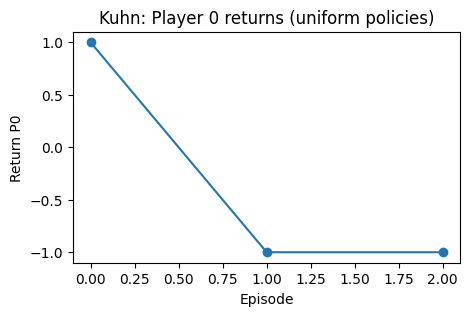


=== LEDUC EPISODE ===
t=00 | C | a=0 (Chance outcome:0) | hist=[]
   infoset: <CHANCE>
t=01 | C | a=1 (Chance outcome:1) | hist=[0]
   infoset: <CHANCE>
t=02 | P0 | a=2 (Raise) | hist=[0, 1]
   infoset: [Observer: 0][Private: 0][Round 1][Player: 0][Pot: 2][Money: 99 99][Round1: ][Round2: ]
t=03 | P1 | a=1 (Call) | hist=[0, 1, 2]
   infoset: [Observer: 1][Private: 1][Round 1][Player: 1][Pot: 4][Money: 97 99][Round1: 2][Round2: ]
t=04 | C | a=2 (Chance outcome:2) | hist=[0, 1, 2, 1]
   infoset: <CHANCE>
t=05 | P0 | a=1 (Call) | hist=[0, 1, 2, 1, 2]
   infoset: [Observer: 0][Private: 0][Round 2][Player: 0][Pot: 6][Money: 97 97][Public: 2][Round1: 2 1][Round2: ]
t=06 | P1 | a=2 (Raise) | hist=[0, 1, 2, 1, 2, 1]
   infoset: [Observer: 1][Private: 1][Round 2][Player: 1][Pot: 6][Money: 97 97][Public: 2][Round1: 2 1][Round2: 1]
t=07 | P0 | a=2 (Raise) | hist=[0, 1, 2, 1, 2, 1, 2]
   infoset: [Observer: 0][Private: 0][Round 2][Player: 0][Pot: 10][Money: 97 93][Public: 2][Round1: 2 1][Round2: 1

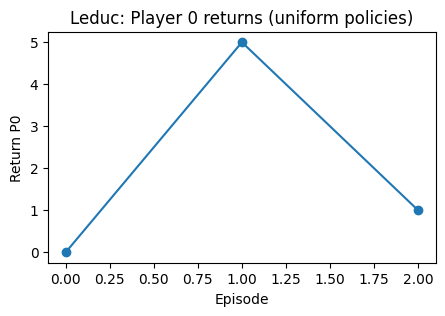

In [5]:
# Clean, chance-safe smoke test for Kuhn & Leduc
# 1) Restart kernel, 2) run this cell only.

import random
import matplotlib.pyplot as plt
import pyspiel

CHANCE = pyspiel.PlayerId.CHANCE  # -1

class OpenSpielEnv:
    def __init__(self, game_name: str):
        self._game = pyspiel.load_game(game_name)
        self._state = None
        self.name = game_name

    # -- thin state wrappers --
    def reset(self): self._state = self._game.new_initial_state()
    def is_terminal(self): return self._state.is_terminal()
    def is_chance(self): return self._state.is_chance_node()
    def current_player(self): return self._state.current_player()
    def legal_actions(self): return self._state.legal_actions()
    def chance_outcomes(self): return self._state.chance_outcomes()
    def step(self, a): self._state.apply_action(a)
    def returns(self): return self._state.returns()
    def info_state(self, player): return self._state.information_state_string(player)
    def action_to_string(self, a): return self._state.action_to_string(a)  # <-- no player arg
    def history(self): return self._state.history()

def sample_chance(outcomes, rng):
    # outcomes: list[(action, prob)]
    r, c = rng.random(), 0.0
    for a, p in outcomes:
        c += p
        if r <= c: return a
    return outcomes[-1][0]

def uniform_act(env, rng):
    return rng.choice(env.legal_actions())

from dataclasses import dataclass
from typing import List, Tuple

@dataclass
class StepLog:
    player: int
    action: int
    action_str: str
    history_ids: list
    info_state: str

def play_episode(env, rng=None) -> Tuple[List[StepLog], List[float]]:
    rng = rng or random.Random(0)
    env.reset()
    logs: List[StepLog] = []
    while not env.is_terminal():
        if env.is_chance():
            a = sample_chance(env.chance_outcomes(), rng)
            logs.append(StepLog(
                player=CHANCE,
                action=a,
                action_str=env.action_to_string(a),
                history_ids=env.history().copy(),
                info_state="<CHANCE>"
            ))
            env.step(a)
            continue

        p = env.current_player()
        a = uniform_act(env, rng)
        # info_state only for real players (>=0)
        infos = env.info_state(p) if p >= 0 else "<NA>"
        logs.append(StepLog(
            player=p,
            action=a,
            action_str=env.action_to_string(a),
            history_ids=env.history().copy(),
            info_state=infos
        ))
        env.step(a)
    return logs, env.returns()

def pretty_print_episode(name, logs, rets):
    print(f"\n=== {name.upper()} EPISODE ===")
    for i, s in enumerate(logs):
        who = "C" if s.player == CHANCE else f"P{s.player}"
        print(f"t={i:02d} | {who} | a={s.action} ({s.action_str}) | hist={s.history_ids}\n   infoset: {s.info_state}")
    print("returns:", rets)

# ---- Run Kuhn ----
rng = random.Random(42)
kuhn = OpenSpielEnv("kuhn_poker")
kuhn_returns = []
for _ in range(3):
    logs, rets = play_episode(kuhn, rng)
    pretty_print_episode("kuhn", logs, rets)
    kuhn_returns.append(rets[0])

plt.figure(figsize=(5,3))
plt.plot(kuhn_returns, marker='o')
plt.title("Kuhn: Player 0 returns (uniform policies)")
plt.xlabel("Episode"); plt.ylabel("Return P0"); plt.show()

# ---- Run Leduc (optional) ----
rng = random.Random(123)
leduc = OpenSpielEnv("leduc_poker")
leduc_returns = []
for _ in range(3):
    logs, rets = play_episode(leduc, rng)
    pretty_print_episode("leduc", logs, rets)
    leduc_returns.append(rets[0])

plt.figure(figsize=(5,3))
plt.plot(leduc_returns, marker='o')
plt.title("Leduc: Player 0 returns (uniform policies)")
plt.xlabel("Episode"); plt.ylabel("Return P0"); plt.show()


## Run a few episodes in **Leduc Hold'em**

### Notes
- In your repo, you'll replace the uniform policy with CFR-derived policies.
- The wrapper methods mirror the `Env` protocol we drafted (`current_player`, `legal_actions`, `observation`, `history`, `step`, `returns`).
- If you want to view human-readable action names, `action_to_string(player, a)` is your friend.
